#  Livrable 1 – Classification binaire d’images

##  Objectif
Développer un modèle de **classification binaire** capable de distinguer :
- **Photos**
- **Autres images** (schémas, textes scannés, peintures…)

Ce livrable constitue la **première étape** du workflow demandé par TouNum.

### Lib import

In [1]:
from keras.src.layers import MaxPooling2D, Conv2D, Dense
from keras import models, layers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

#### Model parameters

In [2]:
img_with = 128
img_height = 128
data_dir = "data/raw"
num_classes = 2
batch_size = 64
epochs = 10

In [3]:
# separate data into training and testing sets
train_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_with, img_height),
    batch_size=batch_size,
)
test_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_with, img_height),
    batch_size=batch_size,
)

Found 41332 files belonging to 2 classes.
Using 33066 files for training.
Found 41332 files belonging to 2 classes.
Using 8266 files for validation.


In [4]:
# get class names
class_names = train_raw.class_names
print(class_names)

['non-photos', 'photos']


In [5]:
# now apply .ignore_errors and the pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_raw.ignore_errors().cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_raw.ignore_errors().cache().prefetch(buffer_size=AUTOTUNE)

2025-10-06 16:33:21.130831: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


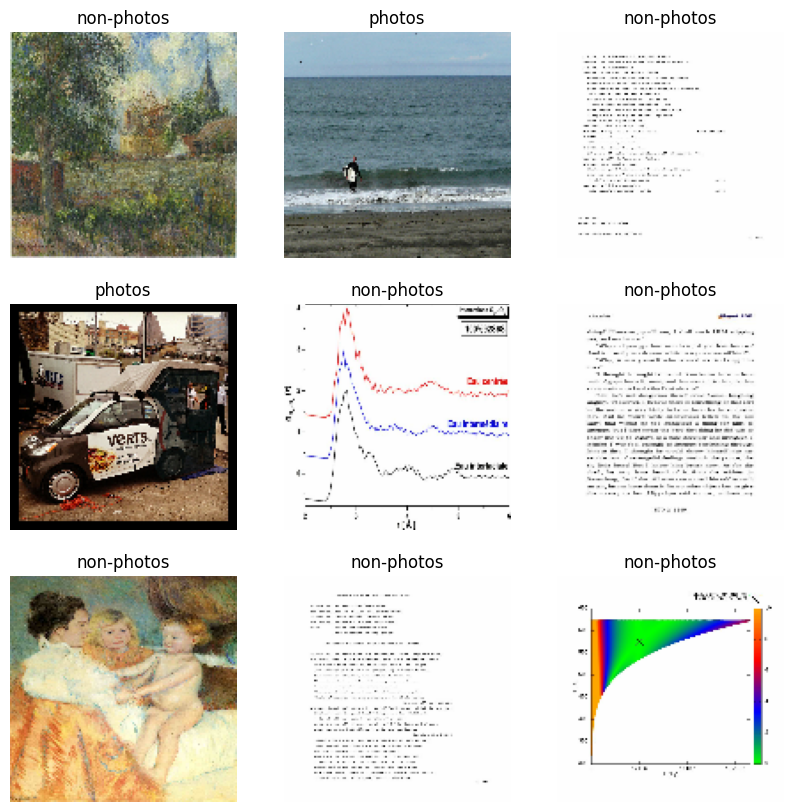

In [6]:
# visualization (use class_names captured above)
plt.figure(figsize=(10, 10))
for images, labels in train_raw.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i].numpy())])
        plt.axis("off")

In [7]:
# standardize data
normalization_layer = layers.Rescaling(1.0 / 255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0].numpy()

2025-10-06 16:33:31.544555: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:16: Filling up shuffle buffer (this may take a while): 176 of 1000
2025-10-06 16:33:37.920388: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-10-06 16:33:51.076439: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


In [8]:
# verify the data is normalized
print(np.min(first_image), np.max(first_image))

0.0020737592 1.0


In [9]:
# Change output layer to 1 neuron with sigmoid
model = models.Sequential([
    layers.Input(shape=(img_with, img_height, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary output
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [10]:
# plot model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,120,993 (8.09 MB)

 Trainable params: 2,120,993 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs
)


Epoch 1/10
    517/Unknown 75s 144ms/step - accuracy: 0.7721 - auc: 0.7666 - loss: 17.0764 - precision: 0.5415 - recall: 0.4645

2025-10-06 16:35:06.267213: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


517/517 ━━━━━━━━━━━━━━━━━━━━ 91s 174ms/step - accuracy: 0.8160 - auc: 0.8567 - loss: 3.5368 - precision: 0.6351 - recall: 0.5737 - val_accuracy: 0.8602 - val_auc: 0.9223 - val_loss: 0.2958 - val_precision: 0.7365 - val_recall: 0.6289
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8721 - auc: 0.9338 - loss: 0.2771 - precision: 0.7482 - recall: 0.7137

2025-10-06 16:37:06.397250: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


517/517 ━━━━━━━━━━━━━━━━━━━━ 112s 216ms/step - accuracy: 0.8743 - auc: 0.9352 - loss: 0.2751 - precision: 0.7537 - recall: 0.7182 - val_accuracy: 0.8797 - val_auc: 0.9401 - val_loss: 0.2750 - val_precision: 0.7150 - val_recall: 0.8098
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 101s 195ms/step - accuracy: 0.8977 - auc: 0.9542 - loss: 0.2319 - precision: 0.8023 - recall: 0.7695 - val_accuracy: 0.8850 - val_auc: 0.9393 - val_loss: 0.2714 - val_precision: 0.7586 - val_recall: 0.7479
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9183 - auc: 0.9685 - loss: 0.1924 - precision: 0.8435 - recall: 0.8130

2025-10-06 16:40:25.501375: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


517/517 ━━━━━━━━━━━━━━━━━━━━ 98s 189ms/step - accuracy: 0.9164 - auc: 0.9674 - loss: 0.1963 - precision: 0.8413 - recall: 0.8093 - val_accuracy: 0.8694 - val_auc: 0.9348 - val_loss: 0.3344 - val_precision: 0.8388 - val_recall: 0.5489
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 95s 185ms/step - accuracy: 0.9299 - auc: 0.9744 - loss: 0.1732 - precision: 0.8677 - recall: 0.8402 - val_accuracy: 0.8897 - val_auc: 0.9442 - val_loss: 0.3073 - val_precision: 0.7425 - val_recall: 0.8108
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 100s 193ms/step - accuracy: 0.9455 - auc: 0.9833 - loss: 0.1377 - precision: 0.8981 - recall: 0.8753 - val_accuracy: 0.8892 - val_auc: 0.9258 - val_loss: 0.3277 - val_precision: 0.7766 - val_recall: 0.7406
Epoch 7/10
 27/517 ━━━━━━━━━━━━━━━━━━━━ 1:33 190ms/step - accuracy: 0.9655 - auc: 0.9924 - loss: 0.0984 - precision: 0.9292 - recall: 0.9305

In [ ]:
# plot training and validation accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
precision = history.history['precision']
val_precision = history.history['val_precision']
recall = history.history['recall']
val_recall = history.history['val_recall']
auc = history.history['auc']
val_auc = history.history['val_auc']

In [ ]:
# plot false positives and false negatives
plt.figure(figsize=(16, 8))
plt.subplot(2, 3, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')